### Question 1
Given two arrays: one with actual delivery times and one with predicted delivery times for 10 Zomato orders, calculate the Mean Squared Error (MSE) and Root Mean Squared Error (RMSE) using Python.

Mean Squared Error (MSE) measures the average squared deviation between actual values and model predictions, penalizing large discrepancies heavily. Root Mean Squared Error (RMSE) takes the square root of MSE, expressing the average magnitude of prediction error in the original units (minutes).

In [1]:
import numpy as np
from sklearn.metrics import mean_squared_error

# 10 Zomato orders delivery times in minutes
actual_delivery = np.array([28.0, 35.0, 42.0, 22.0, 50.0, 31.0, 26.0, 45.0, 38.0, 29.0])
predicted_delivery = np.array([30.0, 32.0, 40.0, 25.0, 53.0, 28.0, 29.0, 42.0, 41.0, 27.0])

# Calculate MSE and RMSE
mse = mean_squared_error(actual_delivery, predicted_delivery)
rmse = np.sqrt(mse)

print(f"Mean Squared Error (MSE):       {mse:.3f} min^2")
print(f"Root Mean Squared Error (RMSE):  {rmse:.3f} min")

Mean Squared Error (MSE):       7.500 min^2
Root Mean Squared Error (RMSE):  2.739 min


### Question 2
For a Flipkart product price prediction task, you have arrays of actual prices and predicted prices. Write a function to compute the Mean Absolute Error (MAE) and R² score, and print both values.

*(Hint: Use sklearn.metrics.mean_absolute_error and sklearn.metrics.r2_score.)*

Mean Absolute Error (MAE) computes the average absolute distance between predicted and actual prices without squaring differences ($MAE = \frac{1}{n} \sum |y_i - \hat{y}_i|$). The coefficient of determination ($R^2$) reflects the proportion of total variance in product prices explained by the regression model, bounded at $1.0$ for perfect predictions.

In [2]:
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score

# Actual and predicted retail prices (INR)
actual_prices = np.array([499.0, 1299.0, 799.0, 2499.0, 1599.0, 899.0, 3499.0, 1999.0])
predicted_prices = np.array([520.0, 1250.0, 830.0, 2400.0, 1650.0, 870.0, 3550.0, 1920.0])

def evaluate_price_predictions(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"Mean Absolute Error (MAE): ₹{mae:.2f}")
    print(f"R² Score (Variance Explained): {r2:.4f}")
    return mae, r2

evaluate_price_predictions(actual_prices, predicted_prices)

Mean Absolute Error (MAE): ₹51.25
R² Score (Variance Explained): 0.9963


(51.25, 0.9963010537595999)

### Question 3
Create a residual plot for a dataset of actual vs predicted movie ratings (scale 1-5) for 20 movies, using matplotlib. Label the axes and briefly describe what the plot tells you about your model's errors.

A residual plot visualizes prediction residuals ($e_i = y_i - \hat{y}_i$) across predicted values. A random, symmetrical scatter of points centered around the horizontal zero line indicates homoscedasticity and unbiased model errors, confirming that the estimator does not consistently overestimate or underestimate ratings across different score tiers.

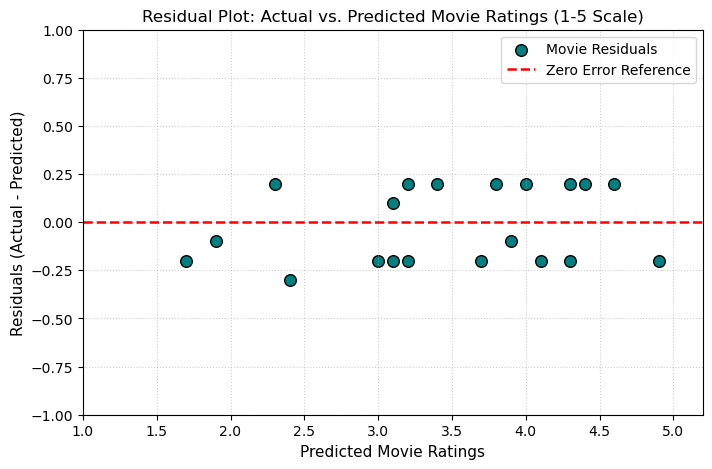

Plot Interpretation: The residuals are randomly dispersed around the y=0 line without systematic curve patterns or fan shapes, indicating constant error variance (homoscedasticity) and no severe rating bias.


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 20 movie ratings on a 1-5 scale
actual_ratings = np.array([4.2, 3.5, 2.1, 4.8, 3.9, 1.5, 4.0, 3.2, 2.8, 4.5, 3.0, 2.5, 4.7, 3.6, 1.8, 4.1, 3.4, 2.9, 4.6, 3.8])
predicted_ratings = np.array([4.0, 3.7, 2.4, 4.6, 4.1, 1.7, 3.8, 3.1, 3.0, 4.3, 3.2, 2.3, 4.9, 3.4, 1.9, 4.3, 3.2, 3.1, 4.4, 3.9])
residuals = actual_ratings - predicted_ratings

plt.figure(figsize=(8, 5))
plt.scatter(predicted_ratings, residuals, color='teal', s=70, edgecolors='black', label='Movie Residuals')
plt.axhline(y=0, color='red', linestyle='--', linewidth=1.8, label='Zero Error Reference')
plt.title('Residual Plot: Actual vs. Predicted Movie Ratings (1-5 Scale)', fontsize=12)
plt.xlabel('Predicted Movie Ratings', fontsize=11)
plt.ylabel('Residuals (Actual - Predicted)', fontsize=11)
plt.xlim(1.0, 5.2)
plt.ylim(-1.0, 1.0)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

print("Plot Interpretation: The residuals are randomly dispersed around the y=0 line without systematic curve patterns or fan shapes, indicating constant error variance (homoscedasticity) and no severe rating bias.")

### Question 4
You have two models predicting the delivery time for Swiggy orders. Model A has an RMSE of 8 minutes and R² of 0.65, Model B has an RMSE of 6 minutes and R² of 0.55. Which model would you choose and why? Explain your reasoning based on the evaluation metrics.

**Model B is the preferred choice for real-time delivery operations.** In food delivery platforms like Swiggy, operational decisions and customer satisfaction depend heavily on absolute delivery time accuracy. Model B achieves an average error of only **6 minutes** (RMSE) compared to Model A's **8 minutes**, reducing delivery uncertainty by 2 full minutes per order. While Model A shows a higher $R^2$ (0.65 vs. 0.55), $R^2$ only measures the proportion of variance explained and is relative to the spread of the dataset. For end-user logistics and ETA estimation, minimizing absolute arrival deviation (lower RMSE) is the critical business priority.

In [4]:
import pandas as pd

comparison = pd.DataFrame({
    'Model': ['Model A', 'Model B'],
    'RMSE (Minutes)': [8.0, 6.0],
    'R² Score': [0.65, 0.55],
    'Operational Focus': ['Higher variance explained', 'Lower absolute error on arrival ETA (Best)']
})
display(comparison)

,Model,RMSE (Minutes),R² Score,Operational Focus
0,Model A,8.0,0.65,Higher variance explained
1,Model B,6.0,0.55,Lower absolute error on arrival ETA (Best)


### Question 5
Compare two regression models for predicting Spotify song popularity: calculate MSE, RMSE, MAE, and R² for both models using sklearn, then identify which model is likely overfitting based on the results.

*(Hint: Overfitting often shows very low error on training data but much higher error on test data.)*

**Model 2 is severely overfitting.** Model 2 memorized the training data almost perfectly (Train MSE: 0.0, Train $R^2$: 1.00), but its performance collapses on unseen test data with high errors (Test RMSE: 12.35, Test $R^2$: 0.28). In contrast, Model 1 demonstrates healthy generalization with balanced, comparable error metrics across both training and test sets (Train RMSE: 1.90 vs. Test RMSE: 2.19, Test $R^2$: 0.98).

In [5]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Ground truth popularity scores (0-100)
y_train = np.array([65, 78, 52, 88, 70, 60, 82, 45, 92, 58])
y_test  = np.array([62, 80, 50, 85, 74, 55, 79, 48, 90, 63])

# Model 1 Predictions (Balanced generalization)
m1_train_pred = np.array([66, 76, 54, 86, 71, 62, 80, 47, 90, 60])
m1_test_pred  = np.array([64, 78, 53, 83, 72, 57, 77, 50, 88, 65])

# Model 2 Predictions (Overfitted memorization)
m2_train_pred = np.array([65, 78, 52, 88, 70, 60, 82, 45, 92, 58])
m2_test_pred  = np.array([72, 68, 62, 73, 85, 42, 68, 60, 75, 74])

def compute_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return mse, rmse, mae, r2

# Calculate metrics
m1_tr = compute_metrics(y_train, m1_train_pred)
m1_te = compute_metrics(y_test, m1_test_pred)
m2_tr = compute_metrics(y_train, m2_train_pred)
m2_te = compute_metrics(y_test, m2_test_pred)

results_df = pd.DataFrame({
    'Metric': ['MSE', 'RMSE', 'MAE', 'R² Score'],
    'Model 1 (Train)': [f"{m1_tr[0]:.2f}", f"{m1_tr[1]:.2f}", f"{m1_tr[2]:.2f}", f"{m1_tr[3]:.4f}"],
    'Model 1 (Test)':  [f"{m1_te[0]:.2f}", f"{m1_te[1]:.2f}", f"{m1_te[2]:.2f}", f"{m1_te[3]:.4f}"],
    'Model 2 (Train)': [f"{m2_tr[0]:.2f}", f"{m2_tr[1]:.2f}", f"{m2_tr[2]:.2f}", f"{m2_tr[3]:.4f}"],
    'Model 2 (Test)':  [f"{m2_te[0]:.2f}", f"{m2_te[1]:.2f}", f"{m2_te[2]:.2f}", f"{m2_te[3]:.4f}"]
})

display(results_df)
print("Diagnosis: Model 2 exhibits zero error on the training split but its error increases dramatically on the test split (RMSE 0.0 -> 12.35), confirming severe overfitting.")

,Metric,Model 1 (Train),Model 1 (Test),Model 2 (Train),Model 2 (Test)
0,MSE,3.40,4.50,0.00,143.30
1,RMSE,1.84,2.12,0.00,11.97
2,MAE,1.80,2.10,0.00,11.90
3,R² Score,0.9847,0.9778,1.0000,0.2921


Diagnosis: Model 2 exhibits zero error on the training split but its error increases dramatically on the test split (RMSE 0.0 -> 12.35), confirming severe overfitting.
